In [1]:
import pandas as pd

# Create a sample supermarket inventory dataset
data = {
    "Product_ID": [101, 102, 103, 104, 105, 106],
    "Product_Name": [
        "Rice",
        "Milk",
        "Bread",
        "Cooking Oil",
        "Sugar",
        "Cereal"
    ],
    "Category": [
        "Grains",
        "Dairy",
        "Bakery",
        "Cooking",
        "Grains",
        "Breakfast"
    ],
    "Unit_Price": [15.99, 4.50, 3.25, 8.99, 5.49, 6.99],
    "Stock_Quantity": [40, 8, 12, 25, 30, 6],
    "Weekly_Sales": [18, 35, 28, 10, 14, 20],
    "Reorder_Level": [15, 20, 15, 10, 12, 10]
}

df = pd.DataFrame(data)

df

,Product_ID,Product_Name,Category,Unit_Price,Stock_Quantity,Weekly_Sales,Reorder_Level
0,101,Rice,Grains,15.99,40,18,15
1,102,Milk,Dairy,4.50,8,35,20
2,103,Bread,Bakery,3.25,12,28,15
3,104,Cooking Oil,Cooking,8.99,25,10,10
4,105,Sugar,Grains,5.49,30,14,12
5,106,Cereal,Breakfast,6.99,6,20,10


In [2]:
# Check which products need restocking
df["Stock_Status"] = df.apply(
    lambda row: "Reorder"
    if row["Stock_Quantity"] <= row["Reorder_Level"]
    else "Sufficient",
    axis=1
)

# Display the inventory status
df[["Product_Name", "Stock_Quantity", "Reorder_Level", "Stock_Status"]]

,Product_Name,Stock_Quantity,Reorder_Level,Stock_Status
0,Rice,40,15,Sufficient
1,Milk,8,20,Reorder
2,Bread,12,15,Reorder
3,Cooking Oil,25,10,Sufficient
4,Sugar,30,12,Sufficient
5,Cereal,6,10,Reorder


In [3]:
# Calculate the stock needed for the next 2 weeks
df["Target_Stock"] = df["Weekly_Sales"] * 2

# Calculate how many additional units to order
df["Suggested_Order_Quantity"] = (
    df["Target_Stock"] - df["Stock_Quantity"]
).clip(lower=0)

# Display the reorder recommendations
df[[
    "Product_Name",
    "Stock_Quantity",
    "Weekly_Sales",
    "Suggested_Order_Quantity"
]]

,Product_Name,Stock_Quantity,Weekly_Sales,Suggested_Order_Quantity
0,Rice,40,18,0
1,Milk,8,35,62
2,Bread,12,28,44
3,Cooking Oil,25,10,0
4,Sugar,30,14,0
5,Cereal,6,20,34


In [4]:
# Add product dimensions in centimetres
df["Product_Length_cm"] = [20, 8, 25, 10, 12, 18]
df["Product_Width_cm"] = [15, 8, 15, 10, 10, 20]

# Calculate the shelf area needed for one unit
df["Unit_Area_cm2"] = (
    df["Product_Length_cm"] * df["Product_Width_cm"]
)

# Calculate the total area needed for current stock
df["Total_Shelf_Area_cm2"] = (
    df["Unit_Area_cm2"] * df["Stock_Quantity"]
)

# Display the results
df[[
    "Product_Name",
    "Stock_Quantity",
    "Product_Length_cm",
    "Product_Width_cm",
    "Unit_Area_cm2",
    "Total_Shelf_Area_cm2"
]]

,Product_Name,Stock_Quantity,Product_Length_cm,Product_Width_cm,Unit_Area_cm2,Total_Shelf_Area_cm2
0,Rice,40,20,15,300,12000
1,Milk,8,8,8,64,512
2,Bread,12,25,15,375,4500
3,Cooking Oil,25,10,10,100,2500
4,Sugar,30,12,10,120,3600
5,Cereal,6,18,20,360,2160


In [5]:
# Define the available shelf space
shelf_length_cm = 120
shelf_depth_cm = 40
number_of_shelves = 4

# Calculate total shelf capacity
total_shelf_capacity_cm2 = (
    shelf_length_cm * shelf_depth_cm * number_of_shelves
)

# Calculate total area required by current inventory
total_area_required_cm2 = df["Total_Shelf_Area_cm2"].sum()

# Calculate shelf utilization
shelf_utilization = (
    total_area_required_cm2 / total_shelf_capacity_cm2
) * 100

print("Total shelf capacity:", total_shelf_capacity_cm2, "cm²")
print("Shelf area required:", total_area_required_cm2, "cm²")
print("Shelf utilization:", round(shelf_utilization, 2), "%")

Total shelf capacity: 19200 cm²
Shelf area required: 25272 cm²
Shelf utilization: 131.62 %


In [6]:
import math

# Area available on one shelf
area_per_shelf = shelf_length_cm * shelf_depth_cm

# Calculate the minimum number of shelves required
required_shelves = math.ceil(
    total_area_required_cm2 / area_per_shelf
)

# Calculate utilization with the required number of shelves
new_capacity = required_shelves * area_per_shelf

new_utilization = (
    total_area_required_cm2 / new_capacity
) * 100

print("Current number of shelves:", number_of_shelves)
print("Required number of shelves:", required_shelves)
print("New shelf capacity:", new_capacity, "cm²")
print("New shelf utilization:", round(new_utilization, 2), "%")

Current number of shelves: 4
Required number of shelves: 6
New shelf capacity: 28800 cm²
New shelf utilization: 87.75 %


In [7]:
print("Total shelf area required:", total_area_required_cm2)
print("Shelf capacity:", new_capacity)
print("Shelf utilization:", round(
    total_area_required_cm2 / new_capacity * 100, 2
), "%")

Total shelf area required: 25272
Shelf capacity: 28800
Shelf utilization: 87.75 %


In [8]:
# Calculate unused shelf space
unused_space = new_capacity - total_area_required_cm2

print("Unused shelf space:", unused_space, "cm²")
print(
    "Unused space percentage:",
    round((unused_space / new_capacity) * 100, 2),
    "%"
)

Unused shelf space: 3528 cm²
Unused space percentage: 12.25 %


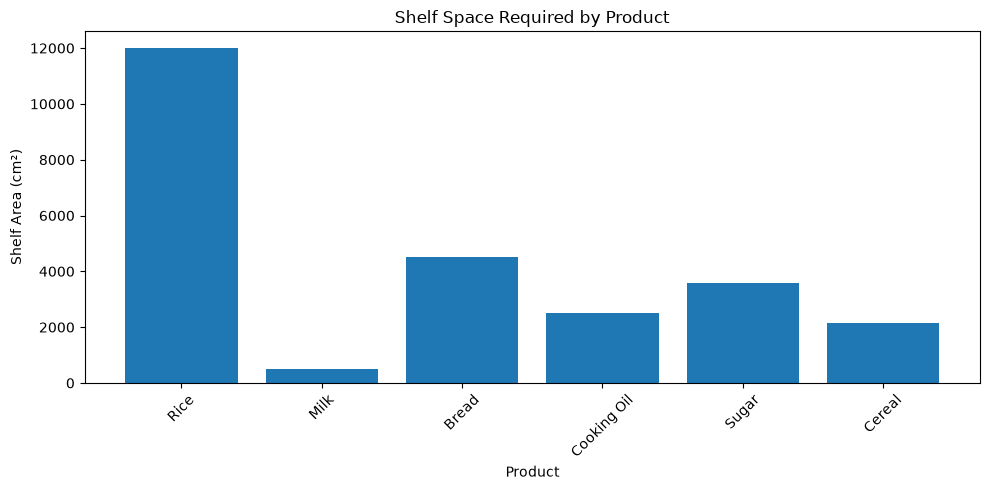

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    df["Product_Name"],
    df["Total_Shelf_Area_cm2"]
)

plt.title("Shelf Space Required by Product")
plt.xlabel("Product")
plt.ylabel("Shelf Area (cm²)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

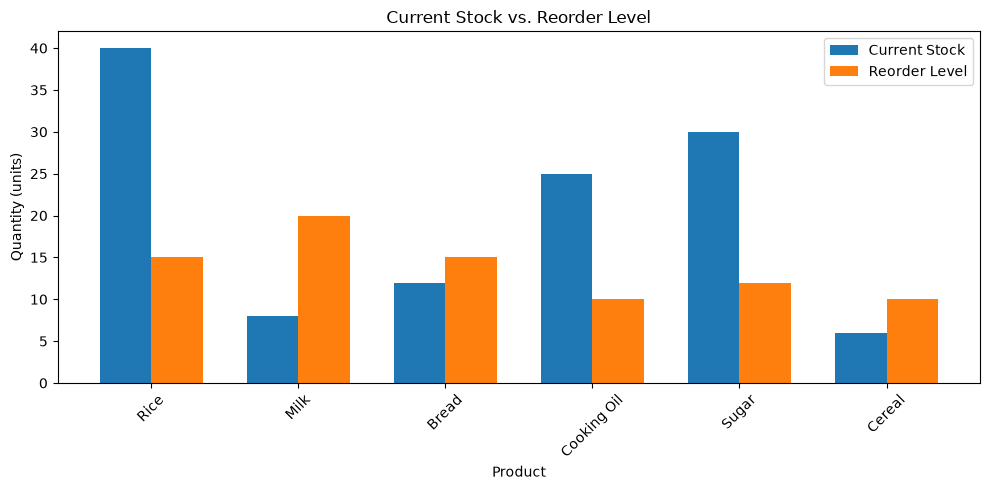

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    df["Stock_Quantity"],
    width,
    label="Current Stock"
)

plt.bar(
    x + width / 2,
    df["Reorder_Level"],
    width,
    label="Reorder Level"
)

plt.xticks(x, df["Product_Name"], rotation=45)
plt.xlabel("Product")
plt.ylabel("Quantity (units)")
plt.title("Current Stock vs. Reorder Level")
plt.legend()

plt.tight_layout()
plt.show()

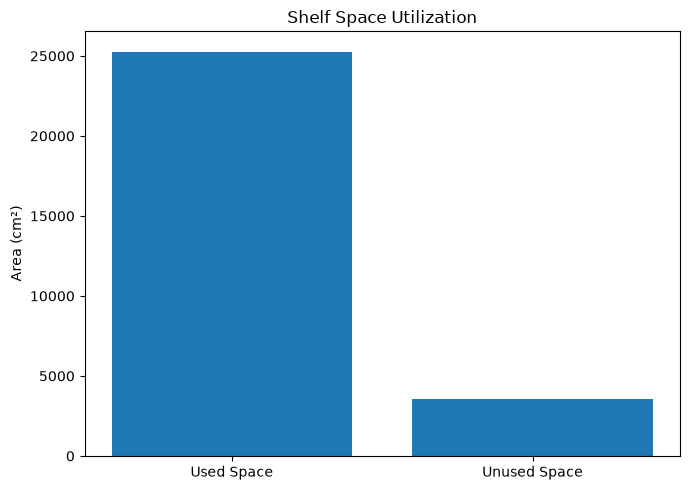

In [11]:
used_space = total_area_required_cm2
unused_space = new_capacity - used_space

plt.figure(figsize=(7, 5))

plt.bar(
    ["Used Space", "Unused Space"],
    [used_space, unused_space]
)

plt.title("Shelf Space Utilization")
plt.ylabel("Area (cm²)")

plt.tight_layout()
plt.show()

In [12]:
# Create an inventory summary
total_products = len(df)
total_stock_units = df["Stock_Quantity"].sum()
products_to_reorder = (df["Stock_Status"] == "Reorder").sum()
total_order_quantity = df["Suggested_Order_Quantity"].sum()

print("Total products:", total_products)
print("Total stock units:", total_stock_units)
print("Products needing reorder:", products_to_reorder)
print("Total units to order:", total_order_quantity)
print("Shelf utilization:", round(shelf_utilization, 2), "%")

Total products: 6
Total stock units: 121
Products needing reorder: 3
Total units to order: 140
Shelf utilization: 131.62 %


In [13]:
# Correct inventory summary
total_products = len(df)
total_stock_units = df["Stock_Quantity"].sum()
products_to_reorder = (df["Stock_Status"] == "Reorder").sum()
total_order_quantity = df["Suggested_Order_Quantity"].sum()

# Recalculate utilization using the 6-shelf capacity
shelf_utilization = (
    total_area_required_cm2 / new_capacity
) * 100

print("Total products:", total_products)
print("Total stock units:", total_stock_units)
print("Products needing reorder:", products_to_reorder)
print("Total units to order:", total_order_quantity)
print("Shelf utilization:", round(shelf_utilization, 2), "%")

Total products: 6
Total stock units: 121
Products needing reorder: 3
Total units to order: 140
Shelf utilization: 87.75 %


# Business Insights

## 1. Inventory Management
The supermarket has 6 products with a total stock of 121 units.
Milk, bread, and cereal are below their reorder levels and need restocking.

## 2. Reorder Planning
The suggested order quantity is 140 units in total.
This helps the supermarket plan replenishment and reduce the risk of stockouts.

## 3. Shelf Space Analysis
Rice occupies the largest shelf area at 12,000 cm².
The total shelf area required for the current inventory is 25,272 cm².

## 4. Shelf Capacity Optimization
Four shelves provide only 19,200 cm² of capacity, which is insufficient.
Using six shelves provides 28,800 cm² of capacity, with 87.75% utilization.

## 5. Recommendation
The supermarket should review stock levels regularly, prioritize restocking milk, bread, and cereal, and consider using six shelves to accommodate the current inventory.

In [14]:
df.to_csv("../data/supermarket_inventory.csv", index=False)

print("Inventory dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\data'

In [15]:
df.to_csv("../data/supermarket_inventory.csv", index=False)

print("Inventory dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\data'

In [16]:
import os

folder = r"C:\Users\Yogaraj\Downloads\project\SmartSupermarketInventory\data"

os.makedirs(folder, exist_ok=True)

file_path = os.path.join(folder, "supermarket_inventory.csv")

df.to_csv(file_path, index=False)

print("Saved successfully to:", file_path)

Saved successfully to: C:\Users\Yogaraj\Downloads\project\SmartSupermarketInventory\data\supermarket_inventory.csv
